In [5]:
## KdV Equation using PINNs
#we use a physics-informed neural network to solve the KdV equation and recover the soliton solution

In [6]:
import torch as torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [7]:
device= torch.device('cuda' if(torch.cuda.is_available()) else 'cpu')
print(device)

cuda


In [8]:
def soliton_solution(x,t,c):
  diff= x- c*t
  prod= torch.sqrt(torch.tensor(c))*diff /2
  prod2= torch.cosh(prod)
  final = -c/ (2*(prod2**2))
  return final

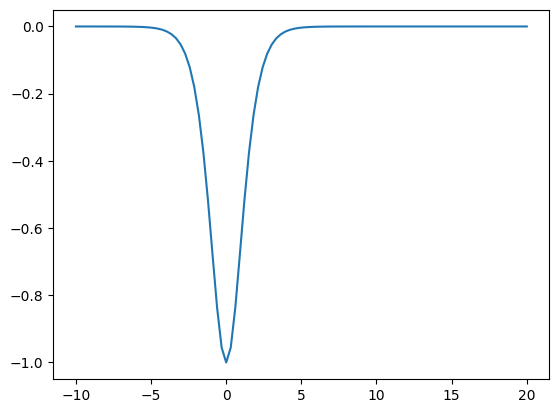

In [9]:
# check whether soliton_solution works as expected
x=torch.linspace(-10,20,100)
t= torch.zeros_like(x)
u=soliton_solution(x,t,c=2)
plt.plot(x.numpy(),u.numpy())
plt.show()


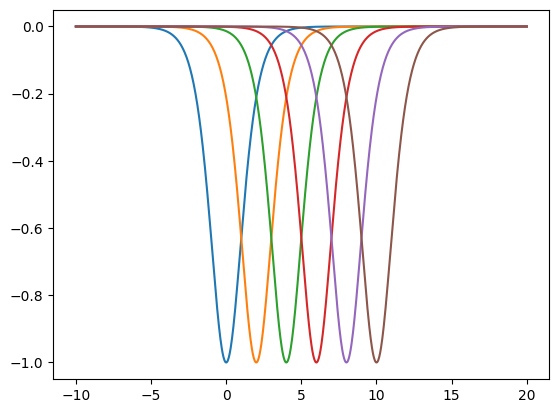

In [10]:
x = torch.linspace(-10, 20, 1000)

for t_val in [0, 1, 2, 3, 4, 5]:
    t = torch.full_like(x, t_val)
    u = soliton_solution(x, t, c=2)
    plt.plot(x.numpy(), u.numpy(), label=f't={t_val}')


plt.show()

In [11]:
## Network

In [12]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = torch.nn.Linear(2, 50)
        self.l2 = torch.nn.Linear(50, 50)
        self.l3 = torch.nn.Linear(50, 50)
        self.l4 = torch.nn.Linear(50, 50)
        self.l5 = torch.nn.Linear(50, 50)
        self.l6 = torch.nn.Linear(50, 50)
        self.out = torch.nn.Linear(50, 1)

        for layer in [self.l1, self.l2, self.l3, self.l4, self.l5, self.l6, self.out]:
            torch.nn.init.xavier_normal_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        inp = torch.tanh(self.l1(inp))
        inp = torch.tanh(self.l2(inp))
        inp = torch.tanh(self.l3(inp))
        inp = torch.tanh(self.l4(inp))
        inp = torch.tanh(self.l5(inp))
        inp = torch.tanh(self.l6(inp))
        return self.out(inp)

In [13]:
model = PINN().to(device)
x_test = torch.rand(5, 1).to(device)
t_test = torch.rand(5, 1).to(device)
print(model(x_test, t_test))

tensor([[0.3740],
        [0.4528],
        [0.1013],
        [0.4306],
        [0.2726]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [14]:
#just calcs derivatives

def derivatives(model, x, t):
    u = model(x, t)

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),create_graph=True)[0]
   # btw by the underscore i mean derivative wrt what

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),create_graph=True)[0]

    u_xxx = torch.autograd.grad(u_xx, x, grad_outputs=torch.ones_like(u_xx),create_graph=True)[0]

    return u, u_t, u_x, u_xxx



In [15]:
# check whether derivatives function works by just calc derivatives the f(x+h)-f(x-h)/2h vala defintion and compare with torch ka grad
x = torch.linspace(-5, 5, 100, requires_grad=True) #this requires grad=True stores the value so that we can calc its derivative in the future and then applies normal derivative tricks to figure out
t = torch.zeros_like(x)
c = 2.0

u = soliton_solution(x, t, c)
u_x_auto = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),create_graph=True)[0]

h = 0.0001
u_plus = soliton_solution(x + h, t, c)
u_minus = soliton_solution(x - h, t, c)
u_x_finite = (u_plus - u_minus) / (2 * h)

print("Autograd give:", u_x_auto[:5].detach().numpy())
print("Finite diff gives:", u_x_finite[:5].detach().numpy())
print("Max difference:", (u_x_auto - u_x_finite).abs().max().item())

Autograd give: [-0.00478822 -0.00552061 -0.0063645  -0.00733672 -0.00845655]
Finite diff gives: [-0.00479515 -0.00552973 -0.0063749  -0.00734348 -0.00847038]
Max difference: 0.0009848922491073608


In [16]:
def pde_loss(model, x, t):
    u, u_t, u_x, u_xxx = derivatives(model, x, t)
    residual = u_t - 6 * u * u_x + u_xxx
    return torch.mean(residual ** 2)

In [17]:
# sets the initial condition value given t=0
def ic_loss(model, x_ic, t_ic, c):
    u_pred = model(x_ic, t_ic)
    u_exact = soliton_solution(x_ic.squeeze(), t_ic.squeeze(), c).unsqueeze(1)
    return torch.mean((u_pred - u_exact) ** 2)

In [18]:
# boundary condn for x=-10 and 20
def bc_loss(model, x_bc, t_bc):
    u_pred = model(x_bc, t_bc)
    return torch.mean(u_pred ** 2)

In [19]:
def data_loss(model, x_data, t_data, u_data):
    u_pred = model(x_data, t_data)
    return torch.mean((u_pred - u_data) ** 2)

In [27]:
def total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data, c):
    loss_pde = pde_loss(model, x_pde, t_pde)
    loss_ic = ic_loss(model, x_ic, t_ic, c)
    loss_bc = bc_loss(model, x_bc, t_bc)
    loss_data = data_loss(model, x_data, t_data, u_data)
    loss = loss_pde + loss_ic + loss_bc + loss_data
    return loss, loss_pde, loss_ic, loss_bc,loss_data
#not using loss weights here since all three losses converge well with equal weights
#if ic or bc loss was stuck while pde kept dropping, we'd weight them higher to balance

In [28]:
## Training Data

In [29]:
#10000 random points across the domain to run on
n_pde = 10000
x_pde = (-10 + 30 * torch.rand(n_pde, 1)).to(device).requires_grad_(True)
t_pde = (5 * torch.rand(n_pde, 1)).to(device).requires_grad_(True)

In [30]:
# synthetic measurement data at random points across the domain
n_data = 200
x_data = (-10 + 30 * torch.rand(n_data, 1)).to(device)
t_data = (5 * torch.rand(n_data, 1)).to(device)
u_data = soliton_solution(x_data.squeeze(), t_data.squeeze(), c=2.0).unsqueeze(1).to(device)

In [31]:
#initial condn 500 points along t=0
n_ic = 500
x_ic = torch.linspace(-10, 20, n_ic).view(-1, 1).to(device).requires_grad_(True)
t_ic = torch.zeros(n_ic, 1).to(device).requires_grad_(True)

In [32]:
#generate points at the left edge (x=−10) and right edge (x=20) for various times
n_bc = 100
t_bc_vals = torch.linspace(0, 5, n_bc).view(-1, 1).to(device)

x_bc_left = torch.full((n_bc, 1), -10.0).to(device).requires_grad_(True)
x_bc_right = torch.full((n_bc, 1), 20.0).to(device).requires_grad_(True)

x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc = torch.cat([t_bc_vals, t_bc_vals], dim=0).requires_grad_(True)

In [33]:
## Training (Adam)

In [48]:
#run 15,000 iterations where the network adjusts its weights to minimize the total loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
pde_losses = []
ic_losses = []
bc_losses = []
data_losses=[]
for i in range(15000):
    optimizer.zero_grad()

    loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data, c=2.0)


    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    pde_losses.append(l_pde.item())
    ic_losses.append(l_ic.item())
    bc_losses.append(l_bc.item())
    data_losses.append(l_data.item())

    if i % 500 == 0:
        print(f"Iter {i:5d} | Total: {loss.item():.6f} | PDE: {l_pde.item():.6f} | IC: {l_ic.item():.6f} | BC: {l_bc.item():.6f} | dataloss: {l_data.item():.6f}")
#

Iter     0 | Total: 0.000001 | PDE: 0.000001 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter   500 | Total: 0.000000 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  1000 | Total: 0.000000 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  1500 | Total: 0.000000 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  2000 | Total: 0.000000 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  2500 | Total: 0.000010 | PDE: 0.000005 | IC: 0.000002 | BC: 0.000001 | dataloss: 0.000002
Iter  3000 | Total: 0.000001 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  3500 | Total: 0.000001 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  4000 | Total: 0.000257 | PDE: 0.000114 | IC: 0.000069 | BC: 0.000024 | dataloss: 0.000050
Iter  4500 | Total: 0.000001 | PDE: 0.000000 | IC: 0.000000 | BC: 0.000000 | dataloss: 0.000000
Iter  5000 | Total: 0.000000 | PDE: 0.00

In [49]:
## Results after Adam

In [50]:
x_test = torch.linspace(-10, 20, 200)
t_test = torch.linspace(0, 5, 100)

X, T = torch.meshgrid(x_test, t_test, indexing='ij')
x_flat = X.reshape(-1, 1).to(device)
t_flat = T.reshape(-1, 1).to(device)

with torch.no_grad():
    u_pred = model(x_flat, t_flat).cpu().numpy().reshape(200, 100)

u_exact = soliton_solution(X.reshape(-1), T.reshape(-1), c=2.0).numpy().reshape(200, 100)

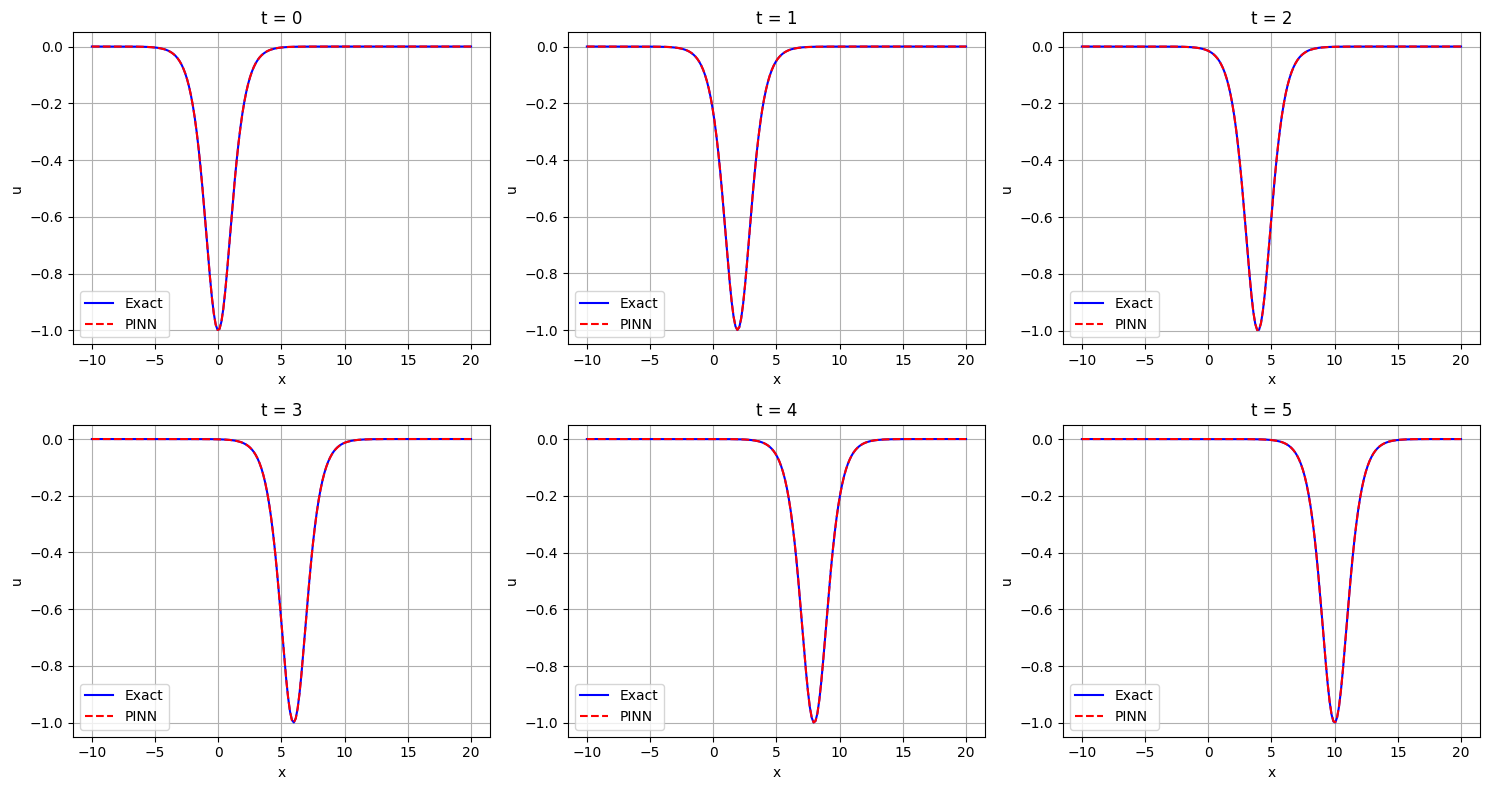

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
times = [0, 1, 2, 3, 4, 5]

for idx, t_val in enumerate(times):
    ax = axes[idx // 3][idx % 3]
    t_idx = int(t_val * 99 / 5)

    ax.plot(x_test.numpy(), u_exact[:, t_idx], 'b-', label='Exact')
    ax.plot(x_test.numpy(), u_pred[:, t_idx], 'r--', label='PINN')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

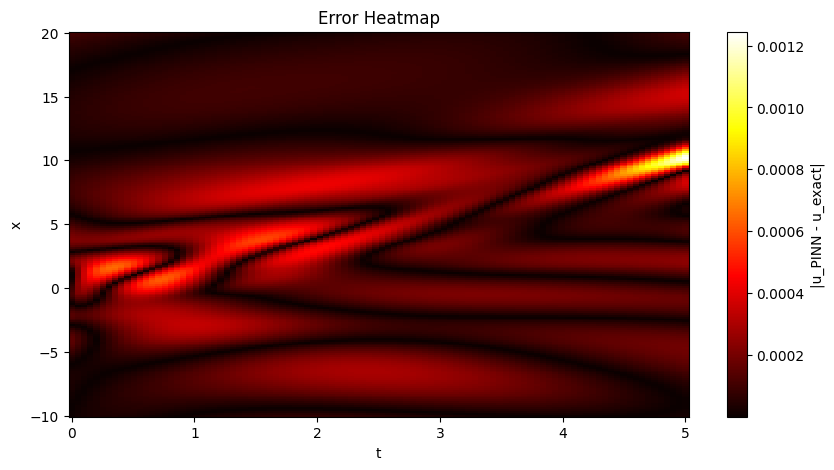

In [52]:
error = np.abs(u_pred - u_exact)
# this is a heatmap of the error btw
plt.figure(figsize=(10, 5))
plt.pcolormesh(t_test.numpy(), x_test.numpy(), error, cmap='hot')
plt.colorbar(label='|u_PINN - u_exact|')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Error Heatmap')
plt.show()

In [53]:
l2_error = np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2))
print(f"L2 Relative Error: {l2_error * 100:.4f}%")

L2 Relative Error: 0.0717%


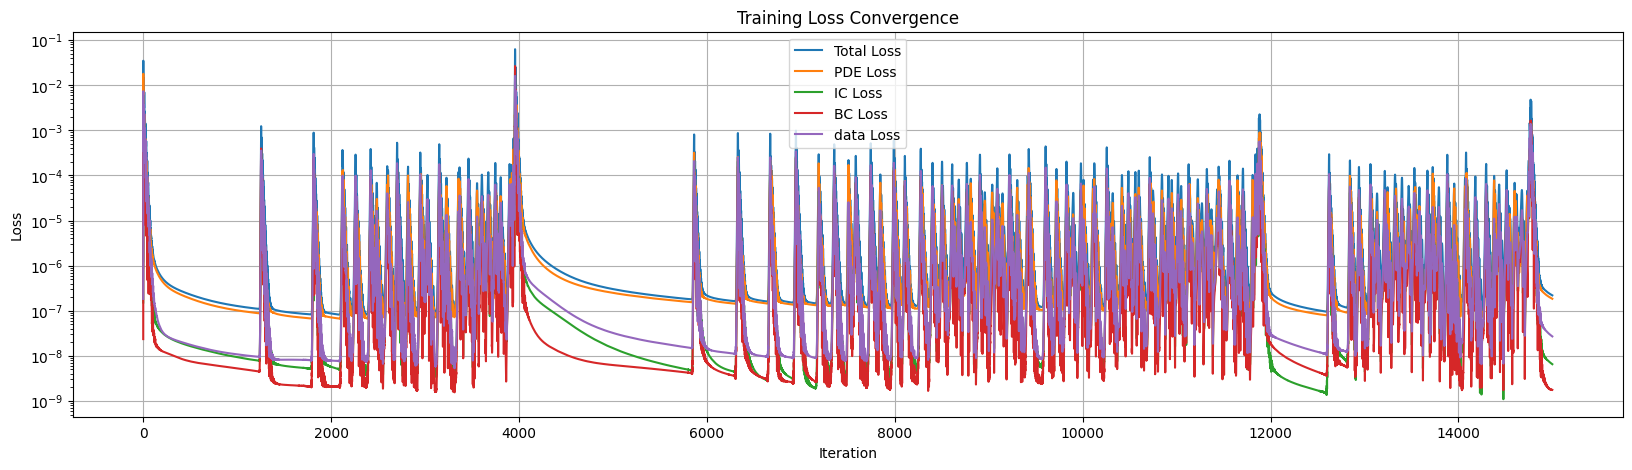

In [54]:
plt.figure(figsize=(20, 5))
plt.plot(losses, label='Total Loss')
plt.plot(pde_losses, label='PDE Loss')
plt.plot(ic_losses, label='IC Loss')
plt.plot(bc_losses, label='BC Loss')
plt.plot(data_losses, label='data Loss')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
## L-BFGS Fine-Tuning
# as we see above the adam loss was ocsillating around 10^-5 without settling. Switching to lbfgs which uses curvature info to converge more precisely.


In [56]:
opt2 = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50)

for i in range(2000):
    def closure():
        opt2.zero_grad()
        loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data, c=2.0)
        loss.backward()
        return loss

    opt2.step(closure)

    if i % 100 == 0:
        loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data, c=2.0)
        print(f"LBFGS {i} | Total: {loss.item():.10f}")

LBFGS 0 | Total: 0.0000002192
LBFGS 100 | Total: 0.0000002192
LBFGS 200 | Total: 0.0000002192
LBFGS 300 | Total: 0.0000002192
LBFGS 400 | Total: 0.0000002192
LBFGS 500 | Total: 0.0000002192
LBFGS 600 | Total: 0.0000002192
LBFGS 700 | Total: 0.0000002192
LBFGS 800 | Total: 0.0000002192
LBFGS 900 | Total: 0.0000002192
LBFGS 1000 | Total: 0.0000002192
LBFGS 1100 | Total: 0.0000002192
LBFGS 1200 | Total: 0.0000002192
LBFGS 1300 | Total: 0.0000002192
LBFGS 1400 | Total: 0.0000002192
LBFGS 1500 | Total: 0.0000002192
LBFGS 1600 | Total: 0.0000002192
LBFGS 1700 | Total: 0.0000002192
LBFGS 1800 | Total: 0.0000002192
LBFGS 1900 | Total: 0.0000002192


In [57]:
## Results after L-BFGS

In [60]:
loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data, c=2.0)
print(f"Total: {loss.item():.12f}")
print(f"PDE: {l_pde.item():.12f}")
print(f"IC: {l_ic.item():.12f}")
print(f"BC: {l_bc.item():.12f}")
print(f"data: {l_data.item():.12f}")

Total: 0.000000219197
PDE: 0.000000183947
IC: 0.000000006522
BC: 0.000000001775
data: 0.000000026953


In [61]:
with torch.no_grad():
    u_pred = model(x_flat, t_flat).cpu().numpy().reshape(200, 100)

u_exact = soliton_solution(X.reshape(-1), T.reshape(-1), c=2.0).numpy().reshape(200, 100)

l2_error = np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2))
print(f"L2 Relative Error: {l2_error * 100:.4f}%")

L2 Relative Error: 0.0717%


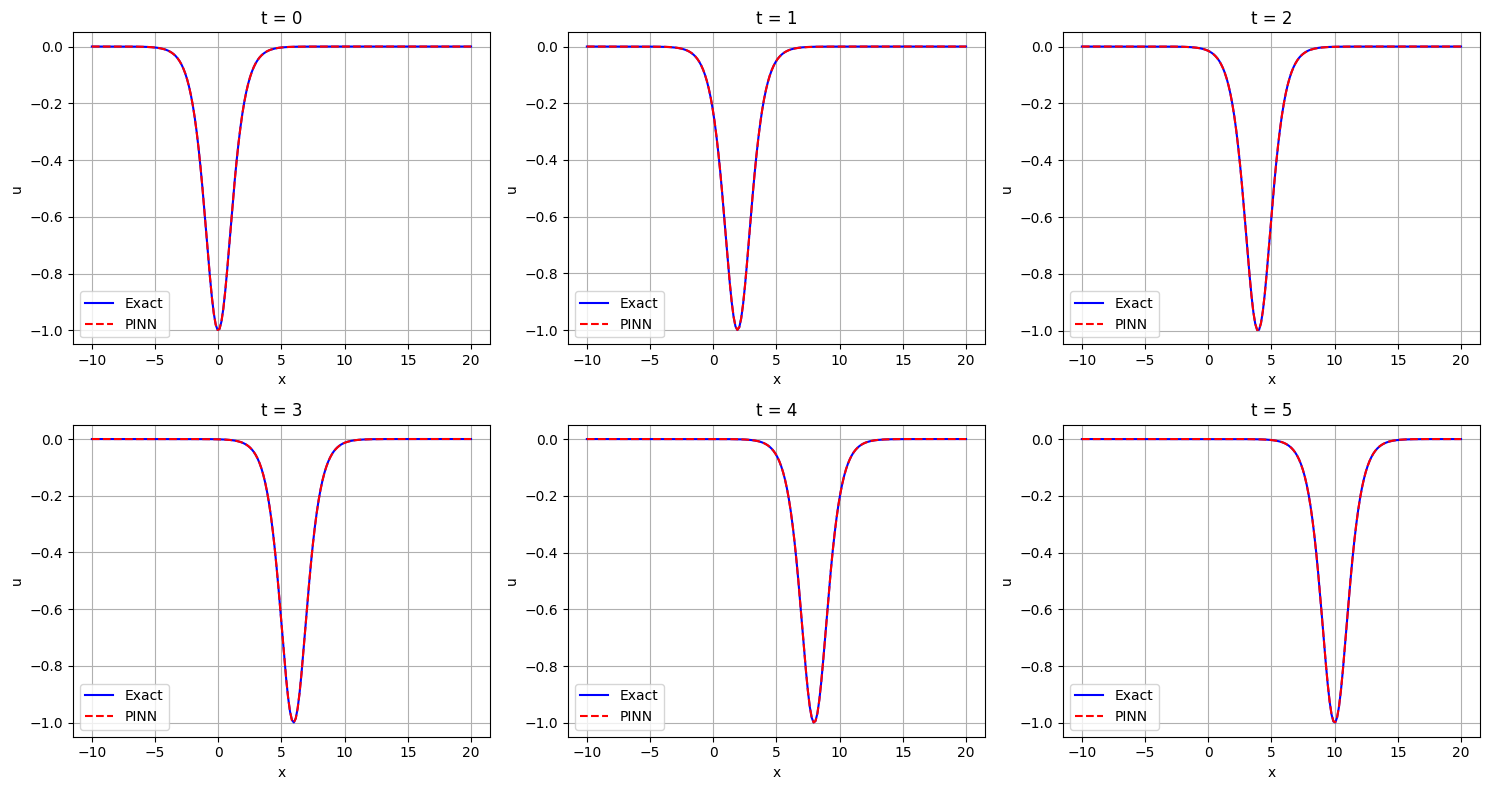

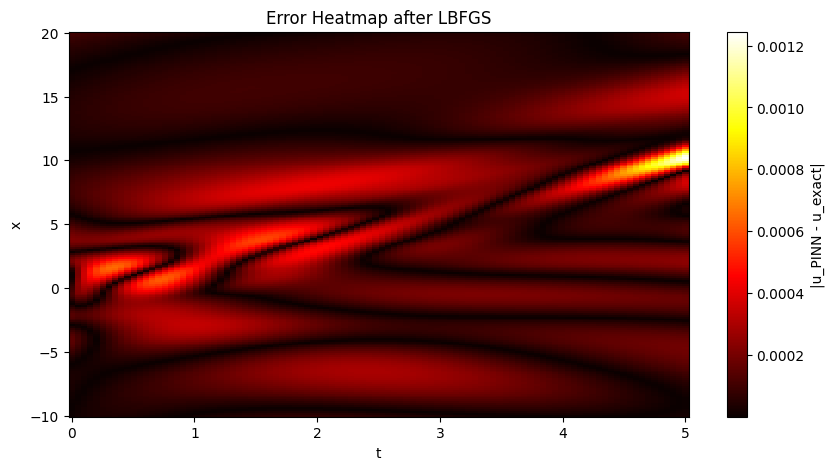

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
times = [0, 1, 2, 3, 4, 5]

for idx, t_val in enumerate(times):
    ax = axes[idx // 3][idx % 3]
    t_idx = int(t_val * 99 / 5)
    ax.plot(x_test.numpy(), u_exact[:, t_idx], 'b-', label='Exact')
    ax.plot(x_test.numpy(), u_pred[:, t_idx], 'r--', label='PINN')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# heatmap
error = np.abs(u_pred - u_exact)
plt.figure(figsize=(10, 5))
plt.pcolormesh(t_test.numpy(), x_test.numpy(), error, cmap='hot')
plt.colorbar(label='|u_PINN - u_exact|')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Error Heatmap after LBFGS')
plt.show()

In [63]:
#check if integral of u over x stays constant (conservation law from KdV)
for t_val in [0, 1, 2, 3, 4, 5]:
    t_idx = int(t_val * 99 / 5)
    integral = np.trapezoid(u_pred[:, t_idx], x_test.numpy())
    print(f"t={t_val} | integral of u dx = {integral:.6f}")

t=0 | integral of u dx = -2.828661
t=1 | integral of u dx = -2.826762
t=2 | integral of u dx = -2.830457
t=3 | integral of u dx = -2.830172
t=4 | integral of u dx = -2.827441
t=5 | integral of u dx = -2.825419


In [64]:
## Summary
#Adam+ lfbgs gives 0.0717% L2 error. Conservation of mass holds across all timesteps (integral stays around -2.82). The PINN learned the travelling wave solution purely from the equation.